<a href="https://colab.research.google.com/github/Harukokoko/Haruka-Nakagawa/blob/main/%E2%98%85calculation_and_result_HS10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ダウンロードデータバージョン。
UNComtradeのAPIはいつrejectされるかわからないので、UNComtradeのサイトから無料ダウンロードしたデータ（HS：HS10、Periods：2023、輸出国：All・相手国：All、TradeFlow：Export、Mode of Transport：TOTAL modes of transport、Customs Codes：TOTAL customs procedure codes）を使用


## 0. 準備

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Callable
import scipy as sp
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import io
import os
from google.colab import files
from google.colab import drive

## 1-1. データダウンロード

## 1-1-1. 今回はExcelでダウンロードしたデータをとりあえず使う

In [ ]:
# # 手動でダウンロード
# uploaded = files.upload()

Saving ex_2023_all_all_HS8482_dlbyfree.xlsx to ex_2023_all_all_HS8482_dlbyfree.xlsx


In [2]:
# Google Driveをマウント
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/16-research/99_Sotsuron/ex_HS10_1995_2023.xlsx'

Mounted at /content/drive


## 1-2. データフレーム化

In [8]:
# ExcelファイルをPandasデータフレームに読み込む
df = pd.read_excel(file_path)

# データフレームを確認
df.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0.0,False,NaN,256605.466,256605.466,0,False,True
1,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0.0,False,NaN,47259.678,47259.678,0,False,True
2,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0.0,False,NaN,88378.555,88378.555,0,False,True
3,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0.0,False,NaN,4704.566,4704.566,0,False,True
4,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0.0,False,NaN,831.215,831.215,0,False,True


##1-2　データ解説

### 抽出指定
商品データ、年次、HSコード、2023年、報告国は指定なし、品目は HSCode20_Cereals（第10塁　穀類）、輸出データ、貿易相手国は指定なし、積送国の指定なし、税関コード指定なし、貿易手段指定なし

## 1-2. データ概観

In [4]:
#　データ数
print("列数：",df.shape[0])
print("行数：",df.shape[1])
print("国数：",len(df['reporterDesc'].unique()))

列数： 156906
行数： 47
国数： 203


## 1-3 欠損値・外れ値処理

In [5]:
df.isnull().sum()

,0
typeCode,0
freqCode,0
refPeriodId,0
refYear,0
refMonth,0
period,0
reporterCode,0
reporterISO,0
reporterDesc,0
flowCode,0


**欠損値が50％以上ある列を削除**

In [6]:
# 欠損値の割合を計算
threshold = 0.5  # 50%以上が欠損している列を削除
df = df.loc[:, df.isna().mean() < threshold]

**reportedDescがWorldの行を削除する**

In [7]:
df = df[df['reporterDesc'] != 'world']
df = df[df['partnerDesc'] != 'world']
# 結果を確認
print(f"Number of rows after filtering: {len(df)}")

Number of rows after filtering: 156906


# 2. ネットワーク可視化

## **▼データ全体のネットワーク化**

In [10]:
import pandas as pd
import networkx as nx

# 必要な列のみ抽出
df = df[["refYear", "reporterDesc", "partnerDesc", "fobvalue"]]

# FOB値が0以下の場合は除外
df = df[df["fobvalue"] > 0]

# ノード名を小文字に統一
df["reporterDesc"] = df["reporterDesc"].str.lower()
df["partnerDesc"] = df["partnerDesc"].str.lower()

# 年ごとにグラフを作成
graphs_by_year = {}

for year, group in df.groupby("refYear"):
    # 有向グラフを作成
    G = nx.DiGraph()

    # エッジを一括追加
    edges = group[["reporterDesc", "partnerDesc", "fobvalue"]].to_dict(orient="records")
    G.add_edges_from([(edge["reporterDesc"], edge["partnerDesc"], {"weight": edge["fobvalue"]}) for edge in edges])

    # 年ごとのグラフを保存
    graphs_by_year[year] = G

    # 年ごとのグラフ情報を表示
    print(f"Year: {year}")
    print(f"  Number of nodes: {G.number_of_nodes()}")
    print(f"  Number of edges: {G.number_of_edges()}")

# 年ごとのグラフが保存された辞書
print(f"Total years processed: {len(graphs_by_year)}")


Year: 1995
  Number of nodes: 220
  Number of edges: 2490
Year: 1996
  Number of nodes: 218
  Number of edges: 2641
Year: 1997
  Number of nodes: 214
  Number of edges: 2735
Year: 1998
  Number of nodes: 214
  Number of edges: 2843
Year: 1999
  Number of nodes: 216
  Number of edges: 3029
Year: 2000
  Number of nodes: 226
  Number of edges: 3344
Year: 2001
  Number of nodes: 224
  Number of edges: 3495
Year: 2002
  Number of nodes: 227
  Number of edges: 3682
Year: 2003
  Number of nodes: 229
  Number of edges: 3899
Year: 2004
  Number of nodes: 229
  Number of edges: 3895
Year: 2005
  Number of nodes: 231
  Number of edges: 3974
Year: 2006
  Number of nodes: 234
  Number of edges: 4287
Year: 2007
  Number of nodes: 226
  Number of edges: 4152
Year: 2008
  Number of nodes: 232
  Number of edges: 4434
Year: 2009
  Number of nodes: 231
  Number of edges: 4431
Year: 2010
  Number of nodes: 233
  Number of edges: 4735
Year: 2011
  Number of nodes: 229
  Number of edges: 4670
Year: 2012
  N

## **▼始点：中国→終点：アメリカ（距離４以下の経路）：subgraph**

Yearly export results saved to 'yearly_export_results.csv'.
   Year  Flow to USA  Direct Export Ratio  Direct Export Amount  \
0  1995     0.004641             0.004641              294397.0   
1  1996     0.000278             0.000277               32929.0   
2  1997     0.000237             0.000125              120136.0   
3  1998     0.000227             0.000227              303054.0   
4  1999     0.009772             0.009772             9225789.0   

   Indirect to Direct Ratio  China's Total FOB Value  \
0                  0.000051             5.806170e+10   
1                  0.001884             5.806170e+10   
2                  0.895962             5.806170e+10   
3                  0.000317             5.806170e+10   
4                  0.000001             5.806170e+10   

   China's Total Export Volume  Estimated Final Flow to USA  
0                 6.343266e+07                 2.944122e+05  
1                 1.187802e+08                 3.299105e+04  
2             

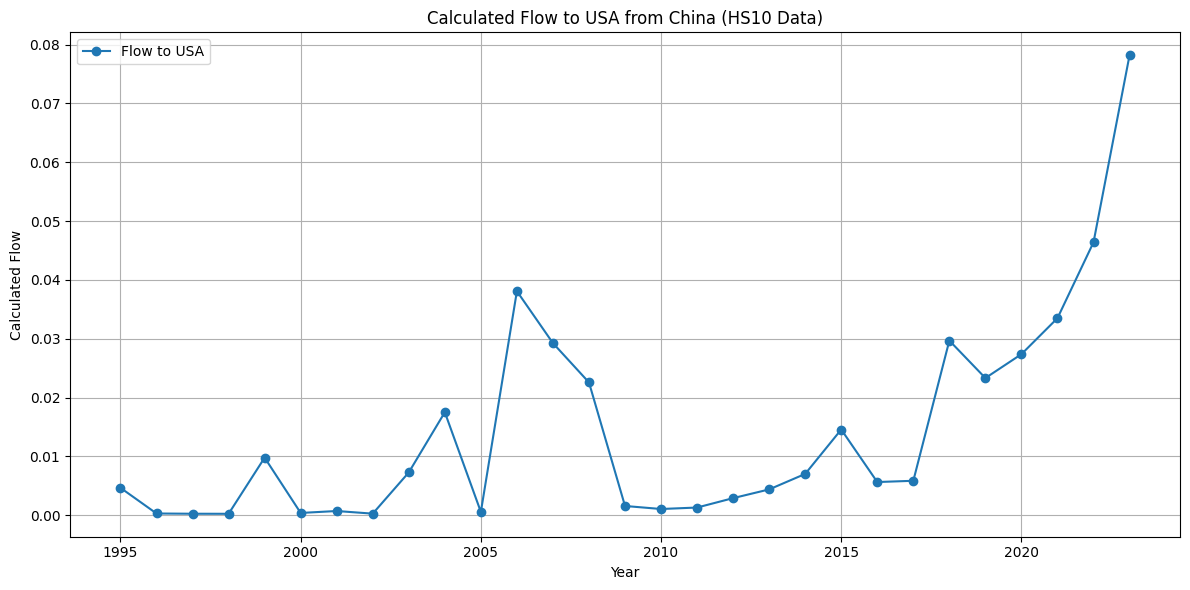

In [17]:
# 基点と終点を設定
source_node = "china"
target_node = "usa"

# 年ごとの結果を保存するリスト
yearly_results = []

# 年ごとにグラフを処理
for year, G in graphs_by_year.items():

    # サブグラフ（距離4以下のノードのみを含む）
    paths_within_distance = list(nx.all_simple_paths(G, source=source_node, target=target_node, cutoff=4))
    nodes_within_paths = set(node for path in paths_within_distance for node in path)
    subgraph = G.subgraph(nodes_within_paths)

    # アメリカへの最終流入量を計算
    usa_flow = calculate_flow_with_stop_on_target(subgraph, source=source_node, target=target_node, weight="weight")

    # 直接輸出割合を計算
    if subgraph.has_edge(source_node, target_node):
        direct_weight = subgraph[source_node][target_node]["weight"]
        total_source_weight = sum(edge_data["weight"] for _, _, edge_data in subgraph.out_edges(source_node, data=True))
        direct_export_ratio = direct_weight / total_source_weight
    else:
        direct_export_ratio = 0  # 直接輸出がない場合

    # 直間比率を計算
    if usa_flow > 0:
        The_ratio_of_di = direct_export_ratio / usa_flow
        The_ratio_of_indi = 1 - The_ratio_of_di
        Indi_to_di = The_ratio_of_indi / The_ratio_of_di
    else:
        The_ratio_of_di = 0
        The_ratio_of_indi = 0
        Indi_to_di = 0

    # 中国の全輸出額を計算
    china_total_fobvalue = df[df["reporterDesc"].str.lower() == "china"]["fobvalue"].sum()

    # サブグラフ内の中国の全輸出額
    if subgraph.has_node("china"):
        china_total_export = sum(edge_data["weight"] for _, _, edge_data in subgraph.out_edges("china", data=True))
    else:
        china_total_export = 0

    # サブグラフ内の中国から米国への直接輸出額
    direct_weight = subgraph[source_node][target_node]["weight"] if subgraph.has_edge(source_node, target_node) else 0

    # アメリカへの推定流入額
    usa_final_estimation = usa_flow * china_total_export

    # 年ごとの結果を保存
    yearly_results.append({
        "Year": year,
        "Flow to USA": usa_flow,
        "Direct Export Ratio": direct_export_ratio,
        "Direct Export Amount": direct_weight,
        "Indirect to Direct Ratio": Indi_to_di,
        "China's Total FOB Value": china_total_fobvalue,
        "China's Total Export Volume": china_total_export,
        "Estimated Final Flow to USA": usa_final_estimation
    })

# データフレームに変換
results_df = pd.DataFrame(yearly_results)

# データフレームをCSVとして保存
results_df.to_csv("yearly_export_results.csv", index=False)
print("Yearly export results saved to 'yearly_export_results.csv'.")

# データフレームの表示
print(results_df.head())

# 折れ線グラフの作成
plt.figure(figsize=(12, 6))

# Flow to USAの折れ線グラフ
plt.plot(results_df["Year"], results_df["Flow to USA"], marker="o", label="Flow to USA")

# グラフの装飾
plt.title("Calculated Flow to USA from China (HS10 Data)")
plt.xlabel("Year")
plt.ylabel("Calculated Flow")
plt.legend()
plt.grid(True)
plt.tight_layout()

# グラフを表示
plt.show()



*   df：全データのデータフレーム
*   G：dfを基にreporter = row["reporterDesc"]、partner = row["partnerDesc"]、weight = row["fobvalue"]で作ったネットワーク
*   subgraph：始点china、終点usaとしたGの部分ネットワーク

In [18]:
results_df.head()

,Year,Flow to USA,Direct Export Ratio,Direct Export Amount,Indirect to Direct Ratio,China's Total FOB Value,China's Total Export Volume,Estimated Final Flow to USA
0,1995,0.004641,0.004641,294397.0,0.000051,5.806170e+10,6.343266e+07,2.944122e+05
1,1996,0.000278,0.000277,32929.0,0.001884,5.806170e+10,1.187802e+08,3.299105e+04
2,1997,0.000237,0.000125,120136.0,0.895962,5.806170e+10,9.604603e+08,2.277733e+05
3,1998,0.000227,0.000227,303054.0,0.000317,5.806170e+10,1.336776e+09,3.031502e+05
4,1999,0.009772,0.009772,9225789.0,0.000001,5.806170e+10,9.440900e+08,9.225799e+06


In [26]:
# 前年比変化率を計算して追加
results_df["DiIndiRatio Change (%)"] = results_df["Indirect to Direct Ratio"].pct_change() * 100

# 変化率の絶対値が大きい年を特定（例: 変化率が50%以上の年）
threshold = 50  # しきい値を設定
significant_years = results_df[results_df["DiIndiRatio Change (%)"].abs() > threshold]["Year"].tolist()

# 結果を保存するリスト
significant_results = []

# 流量が大きく変化した経路を抽出
for year in significant_years:
    # 現在の年と前の年のグラフを取得
    current_graph = graphs_by_year.get(year)
    previous_graph = graphs_by_year.get(year - 1)

    if not previous_graph:
        continue  # 前年のグラフがない場合スキップ

    # 経路ごとの流量を計算
    def calculate_path_flows(G, source, target, cutoff=4):
        path_flows = {}
        paths = list(nx.all_simple_paths(G, source=source, target=target, cutoff=cutoff))
        for path in paths:
            flow = 1.0  # 初期値（起点の流量）
            for i in range(len(path) - 1):
                edge_data = G.get_edge_data(path[i], path[i + 1], default={"weight": 0})
                flow *= edge_data.get("weight", 0)
            path_flows[tuple(path)] = flow
        return path_flows

    # 現在の年と前の年の流量を計算
    current_path_flows = calculate_path_flows(current_graph, source_node, target_node)
    previous_path_flows = calculate_path_flows(previous_graph, source_node, target_node)

    # 流量の変化率を計算
    path_flow_changes = {}
    all_paths = set(current_path_flows.keys()).union(previous_path_flows.keys())
    for path in all_paths:
        current_flow = current_path_flows.get(path, 0)
        previous_flow = previous_path_flows.get(path, 0)
        if previous_flow > 0:  # 前年の流量が0以上の場合に変化率を計算
            change_rate = ((current_flow - previous_flow) / previous_flow) * 100
        else:  # 前年の流量が0の場合は変化率を設定（無限大を避ける）
            change_rate = 100 if current_flow > 0 else 0
        path_flow_changes[path] = change_rate

    # 流量変化率の上位10経路を抽出
    top_10_changes = sorted(
        path_flow_changes.items(), key=lambda x: abs(x[1]), reverse=True
    )[:10]

    # 保存
    significant_results.append({
        "Year": year,
        "DiIndiRatio Change (%)": results_df.loc[results_df["Year"] == year, "DiIndiRatio Change (%)"].values[0],
        "Top 10 Path Changes": {path: change for path, change in top_10_changes}
    })

# 最終結果を年ごとに表示
print("\nSignificant DiIndiRatio Change (%) (Top 10 Paths):")
for result in significant_results:
    print(f"\nYear: {result['Year']} (DiIndiRatio Change (%): {result['DiIndiRatio Change (%)']:.2f}%)")
    print("Top 10 Path Changes:")
    if result["Top 10 Path Changes"]:
        for path, change in result["Top 10 Path Changes"].items():
            print(f"  Path: {' -> '.join(path)}, Change Rate: {change:.2f}%")
    else:
        print("  No significant paths.")



Significant DiIndiRatio Change (%) (Top 10 Paths):

Year: 1996 (DiIndiRatio Change (%): 3559.10%)
Top 10 Path Changes:
  Path: china -> kazakhstan -> netherlands -> egypt -> usa, Change Rate: 212007227.23%
  Path: china -> kazakhstan -> netherlands -> türkiye -> usa, Change Rate: 72915926.36%
  Path: china -> kazakhstan -> netherlands -> sweden -> usa, Change Rate: 18512985.31%
  Path: china -> kazakhstan -> netherlands -> new zealand -> usa, Change Rate: 16596087.70%
  Path: china -> kazakhstan -> netherlands -> italy -> usa, Change Rate: 15266155.39%
  Path: china -> kazakhstan -> netherlands -> united kingdom -> usa, Change Rate: 14409532.77%
  Path: china -> kazakhstan -> netherlands -> slovakia -> usa, Change Rate: 12083183.65%
  Path: china -> kazakhstan -> netherlands -> france -> usa, Change Rate: 10945726.63%
  Path: china -> kazakhstan -> netherlands -> usa, Change Rate: 10806779.88%
  Path: china -> kazakhstan -> netherlands -> southern african customs union (...1999) -> us